<a href="https://colab.research.google.com/github/A1ief/ekstraksi-fitur/blob/main/ekstraksi_fitur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


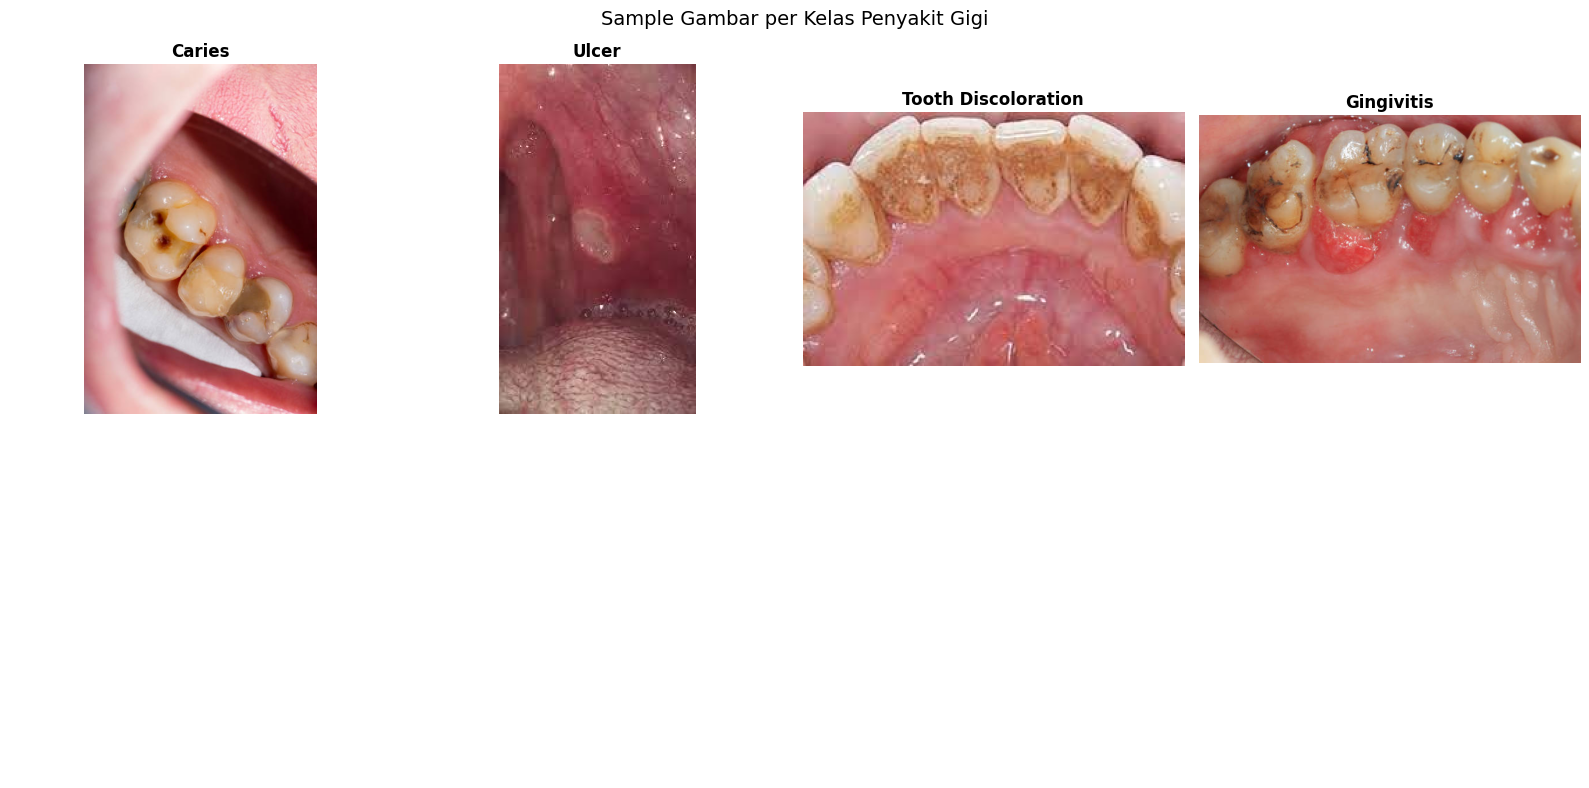

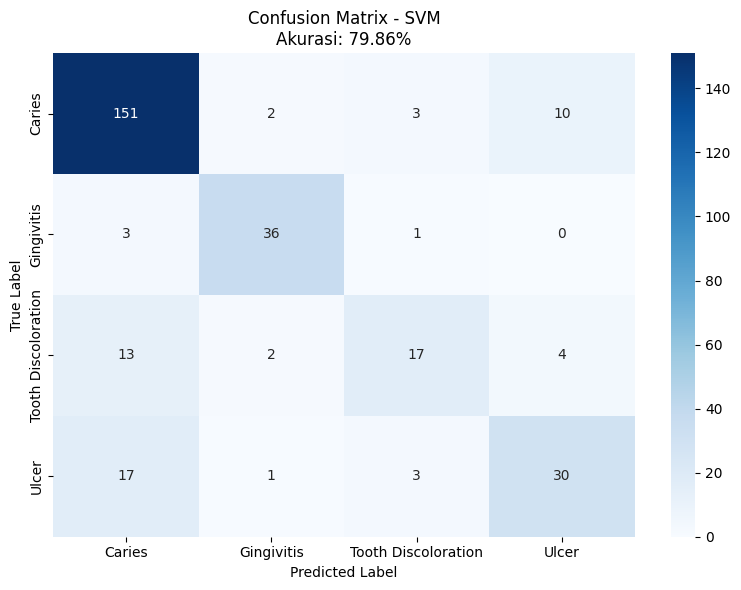

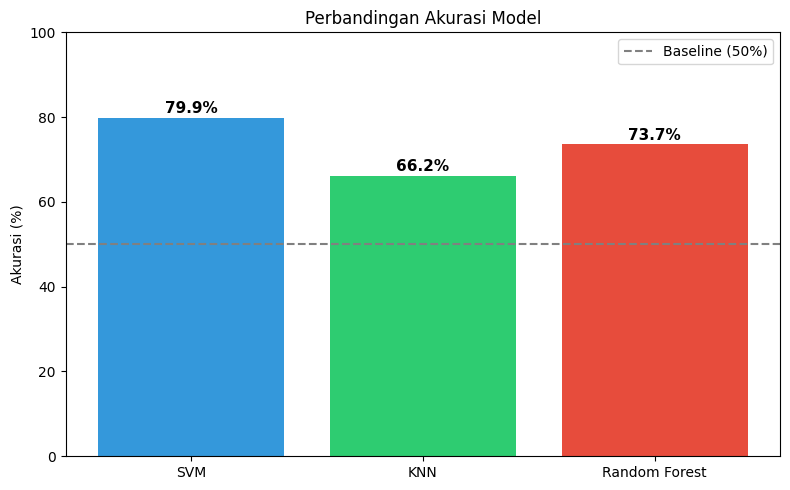

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

# =====================================================
# KONFIGURASI PATH
# =====================================================
IMG_FOLDER = "/content/drive/MyDrive/Colab Notebooks/Data/images/train"
LABEL_FOLDER = "/content/drive/MyDrive/Colab Notebooks/Data/labels/train"
YAML_PATH = "/content/drive/MyDrive/Colab Notebooks/Data/data.yaml"

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/hasil_penyakit_gigi"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(OUTPUT_DIR, "fitur_penyakit_gigi.csv")
CONFUSION_MATRIX_PATH = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
MODEL_COMPARISON_PATH = os.path.join(OUTPUT_DIR, "model_comparison.png")
SAMPLE_IMAGES_PATH = os.path.join(OUTPUT_DIR, "sample_images.png")

IMAGE_SIZE = (128, 128)

with open(YAML_PATH, 'r') as f:
    meta = yaml.safe_load(f)
CLASSES = meta['names']

# =====================================================
# PREPROCESSING
# =====================================================
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None
    img = cv2.resize(img, IMAGE_SIZE)
    img_denoised = cv2.GaussianBlur(img, (3, 3), 0)
    img_gray = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2HSV)
    return img_denoised, img_gray, img_hsv

# =====================================================
# EKSTRAKSI FITUR WARNA
# =====================================================
def extract_color_features(img_bgr, img_hsv):
    hist_b = cv2.calcHist([img_bgr], [0], None, [256], [0, 256]).flatten()
    hist_g = cv2.calcHist([img_bgr], [1], None, [256], [0, 256]).flatten()
    hist_r = cv2.calcHist([img_bgr], [2], None, [256], [0, 256]).flatten()

    hist_b = hist_b / (hist_b.sum() + 1e-7)
    hist_g = hist_g / (hist_g.sum() + 1e-7)
    hist_r = hist_r / (hist_r.sum() + 1e-7)

    h, s, v = cv2.split(img_hsv)
    hsv_features = np.array([
        np.mean(h), np.mean(s), np.mean(v),
        np.std(h), np.std(s), np.std(v)
    ])

    return np.concatenate([hist_r, hist_g, hist_b, hsv_features])

# =====================================================
# EKSTRAKSI FITUR TEKSTUR
# =====================================================
def extract_texture_features(img_gray):
    glcm = graycomatrix(
        img_gray, distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        symmetric=True, normed=True
    )
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy_glcm = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()

    hist, _ = np.histogram(img_gray.flatten(), bins=256, range=(0, 256))
    p = hist / (hist.sum() + 1e-7)
    i = np.arange(256)

    m = np.sum(i * p)
    sigma = np.sqrt(np.sum((i - m)**2 * p))
    skewness = np.sum((i - m)**3 * p)
    energy_h = np.sum(p**2)
    entropy = -np.sum(p * np.log2(p + 1e-7))
    sigma_norm = sigma / 255.0
    R = 1 - (1 / (1 + sigma_norm**2))

    return np.array([
        contrast, dissimilarity, homogeneity, energy_glcm, correlation,
        m, sigma, skewness, energy_h, entropy, R
    ])

# =====================================================
# EKSTRAKSI FITUR BENTUK
# =====================================================
def extract_shape_features(img_bgr, img_gray):
    _, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return np.zeros(8)

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter**2 + 1e-7)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / (h + 1e-7)
    extent = area / (w * h + 1e-7)

    hull = cv2.convexHull(cnt)
    solidity = area / (cv2.contourArea(hull) + 1e-7)

    M = cv2.moments(cnt)
    cx = (M["m10"] / (M["m00"] + 1e-7)) / IMAGE_SIZE[0]
    cy = (M["m01"] / (M["m00"] + 1e-7)) / IMAGE_SIZE[1]

    return np.array([area, perimeter, circularity, aspect_ratio, extent, solidity, cx, cy])

# =====================================================
# GABUNG SEMUA FITUR
# =====================================================
def extract_all_features(img_path):
    img_bgr, img_gray, img_hsv = preprocess_image(img_path)
    if img_bgr is None:
        return None

    color = extract_color_features(img_bgr, img_hsv)
    texture = extract_texture_features(img_gray)
    shape = extract_shape_features(img_bgr, img_gray)

    return np.concatenate([color, texture, shape])

# =====================================================
# BACA LABEL DARI FILE TXT
# =====================================================
def get_label_from_txt(txt_path, classes):
    if not os.path.exists(txt_path):
        return None

    with open(txt_path, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    if not lines:
        return None

    class_id = int(lines[0].split()[0])

    if class_id < len(classes):
        return classes[class_id]
    return None

# =====================================================
# LOAD DATASET YOLO
# =====================================================
def load_dataset_yolo(img_folder, label_folder, classes):
    features_list = []
    labels_list = []

    image_files = [f for f in os.listdir(img_folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    for img_file in image_files:
        img_path = os.path.join(img_folder, img_file)
        base_name = os.path.splitext(img_file)[0]
        txt_path = os.path.join(label_folder, base_name + '.txt')

        label = get_label_from_txt(txt_path, classes)

        if label is None:
            continue

        features = extract_all_features(img_path)

        if features is not None:
            features_list.append(features)
            labels_list.append(label)

    return np.array(features_list), np.array(labels_list)

# =====================================================
# TRAINING & EVALUASI
# =====================================================
def train_and_evaluate(X, y):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    models = {
        "SVM": SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    }

    results = {}
    for name, clf in models.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results[name] = {
            "model": clf,
            "predictions": y_pred,
            "accuracy": acc,
        }

    return results, y_test, le, scaler

# =====================================================
# VISUALISASI SAMPLE GAMBAR
# =====================================================
def visualize_sample_yolo(img_folder, label_folder, classes):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    samples = {c: None for c in classes}

    for img_file in os.listdir(img_folder):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        base_name = os.path.splitext(img_file)[0]
        txt_path = os.path.join(label_folder, base_name + '.txt')

        label = get_label_from_txt(txt_path, classes)
        if label and samples[label] is None:
            samples[label] = img_file

        if all(v is not None for v in samples.values()):
            break

    for idx, c in enumerate(classes):
        if idx >= len(axes):
            break

        img_file = samples.get(c)
        if img_file:
            img_path = os.path.join(img_folder, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{c}", fontsize=12, fontweight='bold')
        else:
            axes[idx].set_title(f"{c} (no sample)")
        axes[idx].axis('off')

    for idx in range(len(classes), len(axes)):
        axes[idx].axis('off')

    plt.suptitle("Sample Gambar per Kelas Penyakit Gigi", fontsize=14)
    plt.tight_layout()
    plt.savefig(SAMPLE_IMAGES_PATH, dpi=150, bbox_inches='tight')
    plt.show()

# =====================================================
# VISUALISASI HASIL (CONFUSION MATRIX & PERBANDINGAN)
# =====================================================
def visualize_results(results, y_test, le):
    # Confusion Matrix
    best_model = max(results, key=lambda x: results[x]['accuracy'])
    y_pred_best = results[best_model]['predictions']

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {best_model}\nAkurasi: {results[best_model]["accuracy"]:.2%}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(CONFUSION_MATRIX_PATH, dpi=150, bbox_inches='tight')
    plt.show()

    # Perbandingan Akurasi
    names = list(results.keys())
    accs = [results[m]['accuracy'] * 100 for m in names]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, accs, color=['#3498db', '#2ecc71', '#e74c3c'])
    plt.ylabel('Akurasi (%)')
    plt.title('Perbandingan Akurasi Model')
    plt.ylim(0, 100)

    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

    plt.axhline(y=50, color='gray', linestyle='--', label='Baseline (50%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(MODEL_COMPARISON_PATH, dpi=150, bbox_inches='tight')
    plt.show()

# =====================================================
# SIMPAN FITUR KE CSV
# =====================================================
def save_features_to_csv(X, y, csv_path):
    n_color = 256*3 + 6
    n_texture = 11
    n_shape = 8

    color_cols = [f"color_{i}" for i in range(n_color)]
    texture_cols = [f"texture_{i}" for i in range(n_texture)]
    shape_cols = ["area", "perimeter", "circularity",
                  "aspect_ratio", "extent", "solidity", "cx", "cy"]

    columns = color_cols + texture_cols + shape_cols
    df = pd.DataFrame(X, columns=columns)
    df.insert(0, "label", y)
    df.to_csv(csv_path, index=False)
    return df

# =====================================================
# MAIN PROGRAM (TANPA PRINT STATEMENT)
# =====================================================
if __name__ == "__main__":
    # STEP 1: Sample gambar
    visualize_sample_yolo(IMG_FOLDER, LABEL_FOLDER, CLASSES)

    # STEP 2: Ekstraksi fitur
    X, y = load_dataset_yolo(IMG_FOLDER, LABEL_FOLDER, CLASSES)

    if len(X) > 0:
        # STEP 3: Simpan CSV
        df = save_features_to_csv(X, y, CSV_PATH)

        # STEP 4: Training & evaluasi
        results, y_test, le, scaler = train_and_evaluate(X, y)

        # STEP 5: Visualisasi hasil
        visualize_results(results, y_test, le)